## 实验课10 RNN预测股票价格
#参照Kaggle的例子，完成股票价格预测  
#（根据前50天的开盘价格趋势，预测今天的开盘价格）   
#使用RNN和LSTM，对比两者的精度差别   
https://www.kaggle.com/datasets/soheiltehranipour/apple-stock-20132018/code

**从本次实验开始，我们正式开始学习有关RNN的原理及使用环节**  
**首先先来介绍一个第三方库——Pandas，常用于数据分析、金融、量化、数据科学等领域，不过它本身和“熊猫”没关系，之所以叫这个名字是因为全称Penel Data（面板数据）的简写刚好就是Panda**  

**在Pandas库中，我们常常使用两个强力的数据结构，它们分别是Series（序列）和DataFrame（数据框）**  
**对于序列Series，我们可以认为它就是一个自带行索引的一维数组，值只有一列，有如下例子：**  

In [1]:
import pandas as pd  #这是约定俗称的习惯，我们总是将pandas简写为pd，就像我们总是将numpy简写为np一样

series1=pd.Series([114,514,1919,810],index=['a','b','c','d'],name='score')

print(series1)

a     114
b     514
c    1919
d     810
Name: score, dtype: int64


**在上述代码块中，我们可以见到行索引index不是0、1、2、3而是a、b、c、d，也就是说Series支持自定义行索引命名**  
**name是我们自定义的列名，在上例中114、514、1919、810就是每条记录的score这个特征的具体值。特别的，我们可以将多个Series拼接成DataFrame**  

**下面我们来介绍DataFrame**  
**对于数据框DataFrame，它是一种二维表格型数据，我们不妨认为它就是一个Excel表格，也就说它拥有一个行索引和多个列，有如下例子:**

In [2]:
import pandas as pd

data = {
    "姓名": ["张三", "李四", "王五"],
    "年龄": [20, 21, 20],
    "成绩": [85, 90, 78]
}

df = pd.DataFrame(data)

print(df)

   姓名  年龄  成绩
0  张三  20  85
1  李四  21  90
2  王五  20  78


**下面我们来展示一下如何将多个Series拼接成一个DataFrame，有如下例子:**

In [3]:
import pandas as pd

series1=pd.Series(['李田所','魔法ZC目录','提丰'])
series2=pd.Series(['114514','325','799'])

df1=pd.DataFrame({
    '姓名':series1,
    '神秘常数':series2
})

print(df1)

       姓名    神秘常数
0     李田所  114514
1  魔法ZC目录     325
2      提丰     799


**同理，我们也可以将一个DataFrame拆成多个Series**  
**并且我们可以通过.value属性来将拆分出来的Series变成ndarray，从而使用reshape来改变形状，这在后面加载数据集的时候有所体现**

In [4]:
series1_temp=df1['姓名']
series2_temp=df1['神秘常数']

print(series1_temp)
print(f'当前的数据类型为:{type(series1_temp)}')
print('-----------------')
print(series2_temp)
print(f'当前的数据类型为:{type(series2_temp)}')
print('-----------------')
print(series1_temp.values)
print(f'当前的数据类型为:{type(series1_temp.values)}')
print('-----------------')
print(series2_temp.values)
print(f'当前的数据类型为:{type(series2_temp.values)}')

0       李田所
1    魔法ZC目录
2        提丰
Name: 姓名, dtype: object
当前的数据类型为:<class 'pandas.core.series.Series'>
-----------------
0    114514
1       325
2       799
Name: 神秘常数, dtype: object
当前的数据类型为:<class 'pandas.core.series.Series'>
-----------------
['李田所' '魔法ZC目录' '提丰']
当前的数据类型为:<class 'numpy.ndarray'>
-----------------
['114514' '325' '799']
当前的数据类型为:<class 'numpy.ndarray'>


**然后我们再来介绍一下有关xsl和csv后缀文件的知识**  
**xls的全称是Excel Spreadsheet，它是Excel 97–2003 的默认二进制文件格式，属于微软专有格式。日常口语里也常把 xls 统称 Excel 表格文件。**  
**csv的全称是是Comma-seperated Value，即“逗号分隔值”，是一种纯文本格式，特点是用逗号/制表符分隔数据体积小读写快所有软件、编程语言都兼容。**  

**特别的，本次实验我们用到的数据集AAPL.xls和AAPL - Jan2018.xls本质上不是xls文件而是csv文件，因为两者的数据都在页表的第A列，且不同值之间都是通过'/'或者','来分隔开的，完全符合csv文件的定义，虽然真实的文件后缀是.xls，但是csv格式的内容决定了最终应该用pd.read_csv而不是pd.read_excel**

**有关前置知识的讲解到此为止，我们正式开始RNN网络的搭建**

**大体思路如下：  
一、训练过程：
训练集AAPL.xls共有1259条记录，不妨记为1'、2'、3'……1259'，设定滑动窗口长度为50，我们每次都用前50条记录来预测当前数值，并与真实数值相比来计算损失，更新参数。  
eg：  
通过1'、2'、3'……50'来得到预测值51''，并与真实值51'比较来计算损失更新参数；  
通过2'、3'、4'……51'来得到预测值52''，并与真实值52'比较来计算损失更新参数；  
……；  
通过1209'、1210'、1211'……1258'来得到预测值1259''，并与真实值比较来更新参数。  
上述过程总共进行了1209轮。**

**二、测试过程：  
特别的，我们需要将训练集AAPL.xls的前50行拼接到测试集AAPL - Jan2018.xls中获得真正的测试集，其总行数为20+50=70，不妨记为1'、2'、3'……50'、1、2、3……20，需要注意的是后20条记录没有真实值，我们需要预测  
同理我们用1'、2'、3'……50'来预测1的真实值；  
用2'、3'、4'……50'、1来预测2的真实值；  
………；  
用20'、21'、22'……50'、1、2、3……19来预测20的真实值。  
上述过程总共进行了20轮**

### 读取数据，只使用收盘价

***!!!源文件应该是写错了，训练集中都是开盘价Open，并没有收盘价Close!!!***

我们先来看看原始数据集，其中原始训练集配置的相对路径为./AAPL - Jan2018.xls，原始测试集配置的相对路径为./AAPL.xls  
下面我们尝试读取其内容

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 文件路径（都在当前文件夹 ./ 下）
path1 = "./AAPL.xls"
path2 = "./AAPL - Jan2018.xls"


df_train = pd.read_csv(path1) 
df_test = pd.read_csv(path2)


print("=== AAPL.xls ===")
print(df_train)

print("\n=== AAPL - Jan2018.xls ===")
print(df_test)

=== AAPL.xls ===
            Date        Open
0       1/2/2013   79.117142
1       1/3/2013   78.268570
2       1/4/2013   76.709999
3       1/7/2013   74.571426
4       1/8/2013   75.601425
...          ...         ...
1254  12/22/2017  174.679993
1255  12/26/2017  170.800003
1256  12/27/2017  170.100006
1257  12/28/2017  171.000000
1258  12/29/2017  170.520004

[1259 rows x 2 columns]

=== AAPL - Jan2018.xls ===
         Date        Open
0    1/2/2018  170.160004
1    1/3/2018  172.529999
2    1/4/2018  172.539993
3    1/5/2018  173.440002
4    1/8/2018  174.350006
5    1/9/2018  174.550003
6   1/10/2018  173.160004
7   1/11/2018  174.589996
8   1/12/2018  176.179993
9   1/16/2018  177.899994
10  1/17/2018  176.149994
11  1/18/2018  179.369995
12  1/19/2018  178.610001
13  1/22/2018  177.300003
14  1/23/2018  177.300003
15  1/24/2018  177.250000
16  1/25/2018  174.509995
17  1/26/2018  172.000000
18  1/29/2018  170.160004
19  1/30/2018  165.529999


### 将数据分为训练集和验证集

特别的，为满足实验需求，我们需要将原始训练集的后50条记录拼接到原始测试集的前面，构成新的测试集

In [2]:
temp = df_train.tail(50)  #.tail()可以指定获取倒数的一段记录

df_test = pd.concat([temp, df_test], ignore_index=True)  #concat即为concatenate的简写，意为“连接”，ignore_index=True可以避免多个从0开始的连续索引

print("新测试集总行数：", len(df_test))
print("\n前55行（前50条来自训练集，后5条是原测试集开头）：")
print(df_test.head(55))

新测试集总行数： 70

前55行（前50条来自训练集，后5条是原测试集开头）：
          Date        Open
0   10/19/2017  156.750000
1   10/20/2017  156.610001
2   10/23/2017  156.889999
3   10/24/2017  156.289993
4   10/25/2017  156.910004
5   10/26/2017  157.229996
6   10/27/2017  159.289993
7   10/30/2017  163.889999
8   10/31/2017  167.899994
9    11/1/2017  169.869995
10   11/2/2017  166.600006
11   11/3/2017  174.000000
12   11/6/2017  172.369995
13   11/7/2017  173.910004
14   11/8/2017  174.660004
15   11/9/2017  175.110001
16  11/10/2017  175.110001
17  11/13/2017  173.500000
18  11/14/2017  173.039993
19  11/15/2017  169.970001
20  11/16/2017  171.179993
21  11/17/2017  171.039993
22  11/20/2017  170.289993
23  11/21/2017  170.779999
24  11/22/2017  173.360001
25  11/24/2017  175.100006
26  11/27/2017  175.050003
27  11/28/2017  174.300003
28  11/29/2017  172.630005
29  11/30/2017  170.429993
30   12/1/2017  169.949997
31   12/4/2017  172.479996
32   12/5/2017  169.059998
33   12/6/2017  167.500000
34   12/7/2017

**特别的，新的测试集的长度并没有问题，只是默认不会全部显示**  
**下面我们来加载Dataset和DataLoader**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler  #用于归一化操作
import torch
import torch.nn as nn
import torch.optim as optim

TIME_STEP = 50  #时间序列长度为50
FEATURE = 'Open'  #常见股票术语：open为开盘价，high为最高价，low为最低价，close为收盘价，amount为成交额，volume为成交量
BATCH_SIZE=1  #特别的，此时我们设置BATCH_SIZE=1，这是因为本任务是一个序列预测任务，我们每次都是选取前50个数据来预测当前数据，
              #当BATCH_SIZE=1时候，一个epoch刚好可以遍历一遍训练集
EPOCHS = 5
LR = 0.0001

scaler = MinMaxScaler((0, 1))  #将开盘价映射到0~1之间
train_scaled = scaler.fit_transform(df_train[[FEATURE]].values)  #fit_transform是“学习数据集分布特征+以此进行归一化操作”
test_scaled = scaler.transform(df_test[[FEATURE]].values)  #transform是“依据fit_transform学习的数据集的分布特征”来进行归一化，这是因为我们前提假设训练集和测试集同分布

class StockDataset(Dataset):
    def __init__(self, data, time_step):
        self.data = torch.FloatTensor(data)
        self.time_step = TIME_STEP

    def __len__(self):
        return len(self.data) - self.time_step

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.time_step]
        y = self.data[idx + self.time_step]
        return x, y

train_dataset = StockDataset(train_scaled, TIME_STEP)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)   #!!!特别注意，时间序列不能打乱！否则训练效果极差

#！！！特别的，我们不设置test_dataset和test_loader，这是因为我们需要动态的向测试集中插入刚预测好的数据，详细代码见后文

### 定义网络  

In [4]:
class MyRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()

        self.input_size=input_size
        self.hidden_size=hidden_size
        self.num_layers=num_layers
        
        self.rnn1 = nn.RNN(input_size, hidden_size, batch_first=True)  #当batch_first=True时，输入RNN的张量为[batch,seq,feature]
                                                                       #当batch_first=False时，输入RNN的张量为[seq,batch,feature]
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.rnn2 = nn.RNN(hidden_size, hidden_size, batch_first=True)  #！！！注意，对于第二个rnn层，其输入维度就不是input_size而是hidden_size了
        self.bn2 = nn.BatchNorm1d(hidden_size)
        
        self.fc = nn.Linear(hidden_size, 1)  #每一个时间点处输出变量的形状都是[1,hidden_size]，需要通过形状为[hidden_size,output_size]的全连接层才能将形状变为[1,output_size]

    def forward(self, x):
        #h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)  #h0实际上可以不用自己手写，如果不传入自己手写的h0的话，Pytorch会默认h0为一个全零张量
                                                                         #并且应该注意到h0的形状是[RNN网络层数，传入样本的批次，隐藏维度大小]
        out, _ = self.rnn1(x)  #此处如果不传入手写h0，则应该写成out,_=self.rnn(x)
                               #且output的维度是[传入样本批次，传入样本的序列长度，隐藏维度大小]，hn的维度是[RNN层数，传入样本的批次，隐藏维度大小]
        out=self.bn1(out.transpose(1,2)).transpose(1,2)  #传入bn层需要保证维度为[传入样本批次，隐藏维度大小，传入样本的序列长度]，因此我们使用了transpose(1,2)，同时要记得最后换回来
        out,_=self.rnn2(out)
        out=self.bn2(out.transpose(1,2)).transpose(1,2)
        
        out = self.fc(out[:, -1, :])  #习惯上使用out[:,-1,:]传入全连接层居多，经过切片以后，形状就刚好是[传入样本批次，隐藏维度大小]
                                      #当然如果非要使用hn也不是不行，传入hn[-1,:,:]，形状也刚好是[传入样本批次，隐藏维度大小]
        return out

#使用LSTM时和使用RNN时几乎没什么区别，不过多了变量cn
class MyLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()

        self.input_size=input_size
        self.hidden_size=hidden_size
        self.num_layers=num_layers
        
        self.lstm1 = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.lstm2 = nn.LSTM(hidden_size,hidden_size,batch_first=True)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        #h0 = torch.zeros(self.num_layers, x.size(0), 64).to(DEVICE)  #同理，也可以不传入手写的c0，Pytorch会默认传入一个全零张量
        #c0 = torch.zeros(self.num_layers, x.size(0), 64).to(DEVICE)
        out, _ = self.lstm1(x)
        out=self.bn1(out.transpose(1, 2)).transpose(1, 2)
        out,_=self.lstm2(out)
        out=self.bn2(out.transpose(1, 2)).transpose(1, 2)
        
        out = self.fc(out[:, -1, :])
        
        return out

### 训练网络

**需要特别说明的是，我们接下来会通过绘图来直观比较在训练集上，模型预测值和真实值的差距，由于我们训练了多个epoch，而每个epoch都会完整地遍历一遍训练集，因此真实值图像实际上具有周期，详细效果见下图**

#### 训练RNN网络

Epoch  1 | Loss: 56.117925
Epoch  2 | Loss: 30.383547
Epoch  3 | Loss: 21.348811
Epoch  4 | Loss: 15.733820
Epoch  5 | Loss: 12.337528


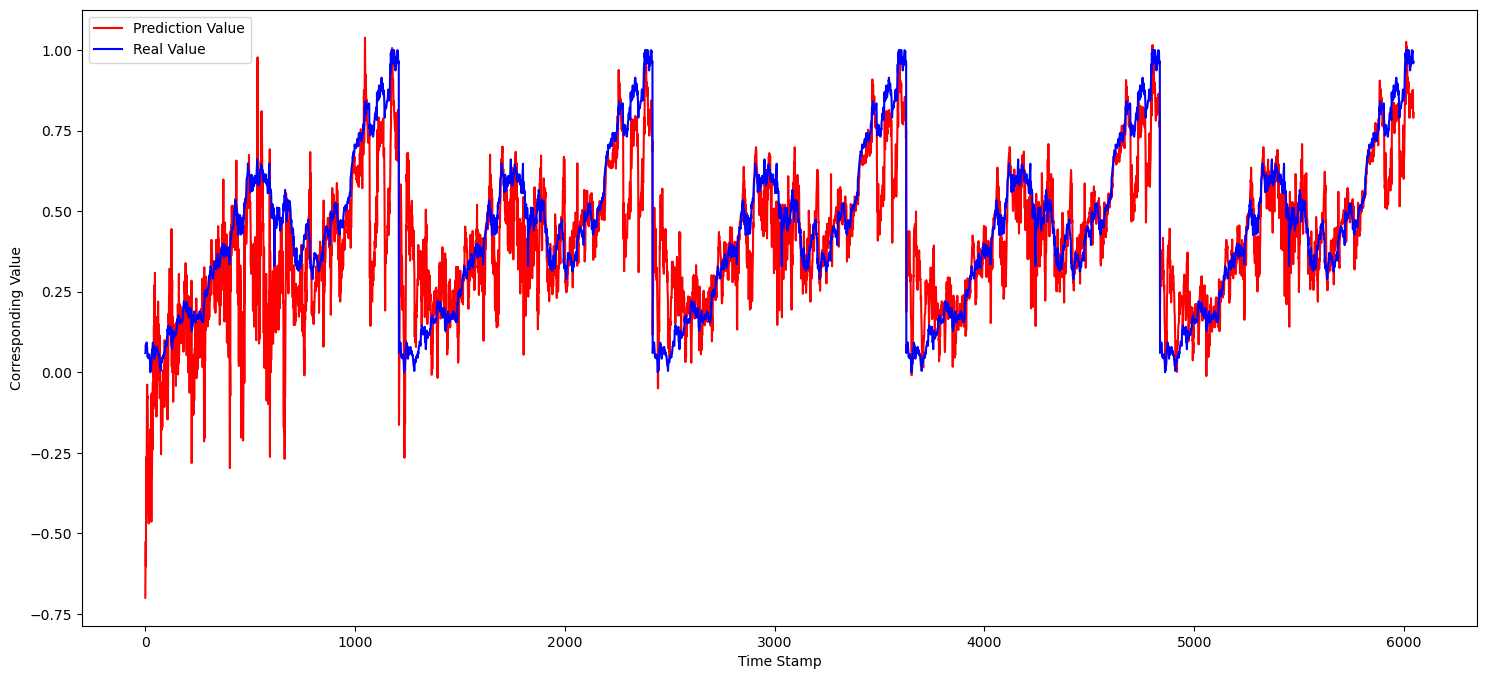

In [6]:
rnn_model = MyRNN()
 
train_losses = []
val_losses = []

stock_prediction=[]
stock_real=[]
date=[]

def train_rnn(model, loader, epochs, lr):
    criterion = nn.MSELoss()  #此处使用的损失函数是均方差损失
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    model.train()

    date_temp=1
    
    for epoch in range(1,epochs+1):
        loss_sum = 0
        for x, y in loader:
            pred = model(x)
            
            stock_prediction.append(pred.item())
            stock_real.append(y.item())
            date.append(date_temp)
            date_temp+=1
            
            loss = criterion(pred, y)
            opt.zero_grad()
            loss.backward()
            opt.step()
            loss_sum += loss.item()
        
        print(f"Epoch {epoch:2d} | Loss: {loss_sum:.6f}")
            
    return model

rnn_model=train_rnn(rnn_model,train_loader,EPOCHS,LR)

plt.figure(figsize=(18,8))
plt.plot(date,stock_prediction,color='red',label='Prediction Value')
plt.plot(date,stock_real,color='blue',label='Real Value')
plt.xlabel('Time Stamp')
plt.ylabel('Corresponding Value')
plt.legend()
plt.show()

**从损失来看，RNN模型初始损失较大，损失收敛较慢，最终损失也较大**  
**从预测值图像来看，RNN模型的预测曲线和真实曲线差距较大，主要表现为震荡过于激烈（多处震荡值远远偏离此刻的真实值）**

#### 训练LSTM网络

Epoch  1 | Loss: 10.071154
Epoch  2 | Loss: 8.428604
Epoch  3 | Loss: 7.196325
Epoch  4 | Loss: 6.250074
Epoch  5 | Loss: 5.509370


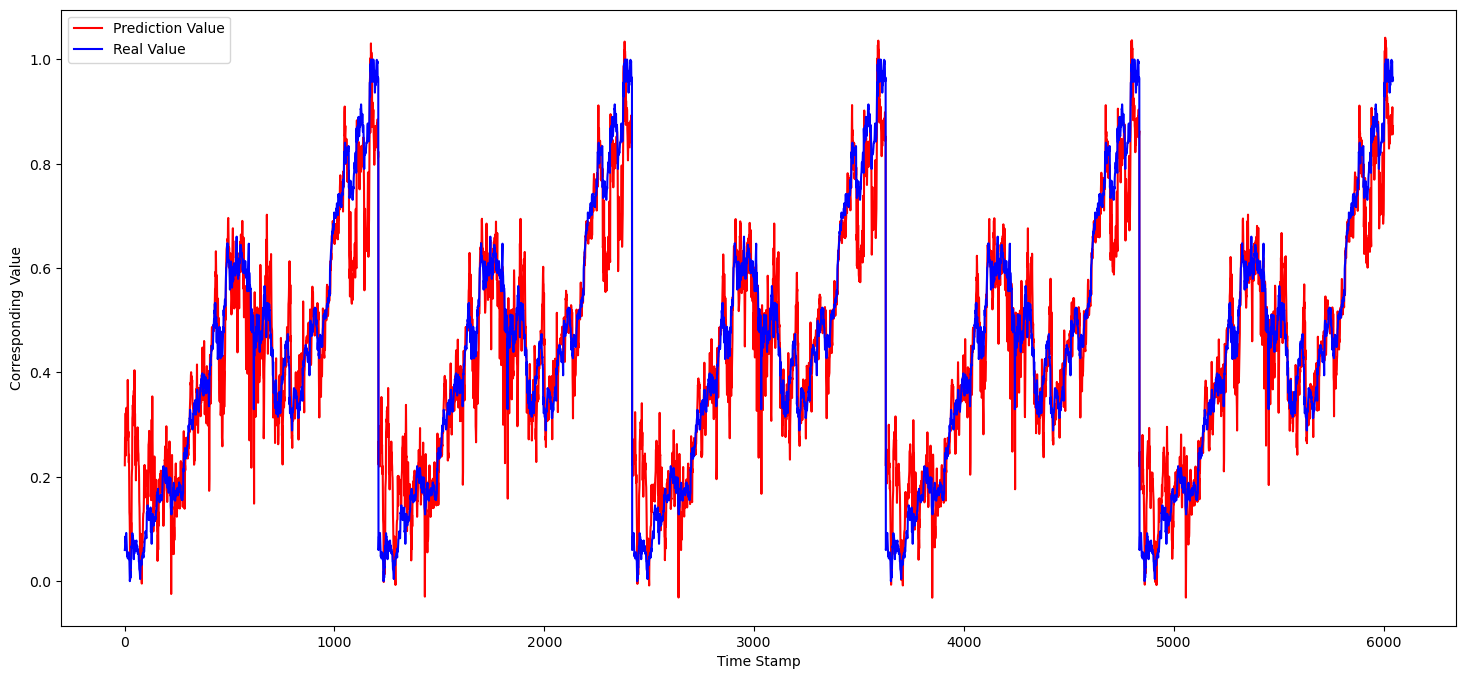

In [8]:
lstm_model = MyLSTM()
 
stock_prediction=[]
stock_real=[]
date=[]

def train_rnn(model, loader, epochs, lr):
    criterion = nn.MSELoss()  
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    model.train()

    date_temp=1
    
    for epoch in range(1,epochs+1):
        loss_sum = 0
        for x, y in loader:
            pred = model(x)
            
            stock_prediction.append(pred.item())
            stock_real.append(y.item())
            date.append(date_temp)
            date_temp+=1
            
            loss = criterion(pred, y)
            opt.zero_grad()
            loss.backward()
            opt.step()
            loss_sum += loss.item()
        
        print(f"Epoch {epoch:2d} | Loss: {loss_sum:.6f}")
            
    return model

rnn_model=train_rnn(rnn_model,train_loader,EPOCHS,LR)

plt.figure(figsize=(18,8))
plt.plot(date,stock_prediction,color='red',label='Prediction Value')
plt.plot(date,stock_real,color='blue',label='Real Value')
plt.xlabel('Time Stamp')
plt.ylabel('Corresponding Value')
plt.legend()
plt.show()

**从损失来看，LSTM模型初始时损失就较小，且损失收敛较快，最终损失也较小**  
**从预测值图像来看，LSTM模型也存在震荡问题，但是震荡的幅度和频率都较小，整体曲线走向和真实图像的重合度更高**

#### 在验证集上验证

**通过观察真实图像的分布我们可以发现，如果我们取训练集后50条记录作为初始的预测依据，那么应该对应每个周期中的最高高峰段**  
**预测结果也应该基本符合最高高峰段的特点**

#### 验证RNN网络

第1个时间戳的股票收盘价预测值为：164.533471
第2个时间戳的股票收盘价预测值为：156.617152
第3个时间戳的股票收盘价预测值为：133.048308
第4个时间戳的股票收盘价预测值为：50.548552
第5个时间戳的股票收盘价预测值为：-77.499981
第6个时间戳的股票收盘价预测值为：-235.428931
第7个时间戳的股票收盘价预测值为：-327.401764
第8个时间戳的股票收盘价预测值为：-261.886631
第9个时间戳的股票收盘价预测值为：-219.480324
第10个时间戳的股票收盘价预测值为：-256.936527
第11个时间戳的股票收盘价预测值为：-259.537406
第12个时间戳的股票收盘价预测值为：-267.586528
第13个时间戳的股票收盘价预测值为：-263.145694
第14个时间戳的股票收盘价预测值为：-246.003913
第15个时间戳的股票收盘价预测值为：-231.020399
第16个时间戳的股票收盘价预测值为：-213.411095
第17个时间戳的股票收盘价预测值为：-194.879958
第18个时间戳的股票收盘价预测值为：-176.381438
第19个时间戳的股票收盘价预测值为：-155.273735
第20个时间戳的股票收盘价预测值为：-133.752213


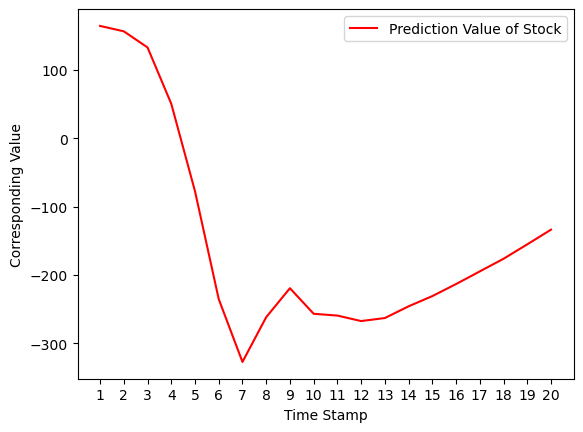

In [31]:
stock_prediction=[]
date=[]

seq = test_scaled[:TIME_STEP].tolist()

criterion = nn.MSELoss() 

date_temp=1

with torch.no_grad():
    for idx in range(len(test_scaled)-TIME_STEP):
        date.append(date_temp)
        date_temp+=1

        x=seq[-TIME_STEP:]
        x=torch.tensor(x).unsqueeze(0)  #squeeze意为“挤压”，实际上是维度上的压缩，而unsqueeze则恰好相反，是维度上的增加
                                        #这是因为我们要保证传入的样本的形状是[批量数，长度，特征数]，
                                        #前面使用train_laoder的时候无论BATCH_SIZE设置为多少，总能保证有一个“批量数”，此处需要我们手动添加
        
        pred=rnn_model(x)
        stock_prediction.append(pred.item())
        
        seq.append([pred.item()])

        
final_pred = scaler.inverse_transform(np.array(stock_prediction).reshape(-1,1)).flatten()  #反归一化，让预测数据恢复为原始数据集中的分布
                                                                                           #这里的flatten()用来将二维数组压缩为一维数组，方便后面plt绘图

for idx in range(len(test_scaled)-TIME_STEP):
    print(f'第{idx+1}个时间戳的股票收盘价预测值为：{final_pred[idx]:.6f}')

plt.figure()
plt.plot(date,final_pred,color='red',label='Prediction Value of Stock')
plt.xticks(date) 
plt.xlabel('Time Stamp')
plt.ylabel('Corresponding Value')
plt.legend()
plt.show()

**可以看到RNN模型最后的预测图像十分不可信，根本看不出来任何和最高高峰段有关联的地方，甚至预测值还出现了负值**

#### 验证LSTM网络

第1个时间戳的股票收盘价预测值为：95.687210
第2个时间戳的股票收盘价预测值为：197.846370
第3个时间戳的股票收盘价预测值为：165.358448
第4个时间戳的股票收盘价预测值为：156.514789
第5个时间戳的股票收盘价预测值为：171.183059
第6个时间戳的股票收盘价预测值为：171.061484
第7个时间戳的股票收盘价预测值为：155.595795
第8个时间戳的股票收盘价预测值为：163.787994
第9个时间戳的股票收盘价预测值为：174.818556
第10个时间戳的股票收盘价预测值为：160.072256
第11个时间戳的股票收盘价预测值为：157.624013
第12个时间戳的股票收盘价预测值为：169.859792
第13个时间戳的股票收盘价预测值为：167.729689
第14个时间戳的股票收盘价预测值为：156.403144
第15个时间戳的股票收盘价预测值为：162.389935
第16个时间戳的股票收盘价预测值为：168.443998
第17个时间戳的股票收盘价预测值为：160.451547
第18个时间戳的股票收盘价预测值为：158.737874
第19个时间戳的股票收盘价预测值为：164.793949
第20个时间戳的股票收盘价预测值为：164.098130


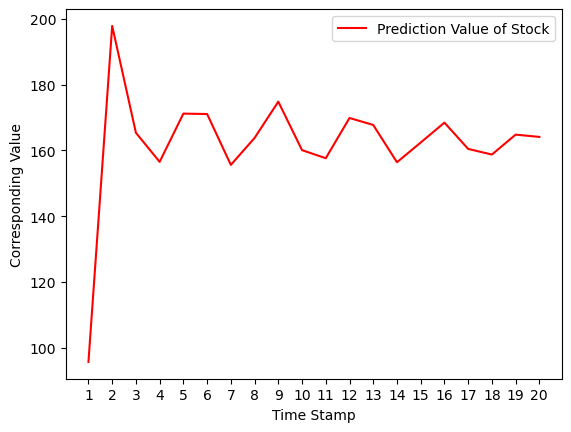

In [32]:
stock_prediction=[]
date=[]

seq = test_scaled[:TIME_STEP].tolist()

criterion = nn.MSELoss() 

date_temp=1

with torch.no_grad():
    for idx in range(len(test_scaled)-TIME_STEP):
        date.append(date_temp)
        date_temp+=1

        x=seq[-TIME_STEP:]
        x=torch.tensor(x).unsqueeze(0)
        
        pred=lstm_model(x)
        stock_prediction.append(pred.item())
        
        seq.append([pred.item()])

final_pred = scaler.inverse_transform(np.array(stock_prediction).reshape(-1,1)).flatten()

for idx in range(len(test_scaled)-TIME_STEP):
    print(f'第{idx+1}个时间戳的股票收盘价预测值为：{final_pred[idx]:.6f}')

plt.figure()
plt.plot(date,final_pred,color='red',label='Prediction Value of Stock')
plt.xticks(date) 
plt.xlabel('Time Stamp')
plt.ylabel('Corresponding Value')
plt.legend()
plt.show()

**LSTM模型的预测值先是从90+开始激增，最后在170左右徘徊，非常符合训练集中后50条记录的分布特点，可以说模型训练的比较成功了**

### 总结

**关于为什么RNN模型预测效果不好，但是LSTM模型预测效果比较好，有如下的解释：**  
**RNN因为梯度消失问题，导致前面学习的早期信息传递不到后面，模型总是只能用前几步学习到的临时信息来预测输出，因此RNN只能学习短期规律，而学习不了长期规律**  
**而LSTM的三个门控单元（输入门——决定记住什么、输出门——决定输出什么、遗忘门——决定遗忘什么）使得其成为了一个简单的“记忆细胞”，能把重要的信息一直保留，从而能学习到长期的规律**

### 评分标准：
#测试精度越高，得分越高   
#代码尽量简洁高效，不包含实验题目无关的函数、代码  
#按照题目大纲编写程序  
#课上能够完成加分   
#实验结果完整、格式规范   
#图文并茂、实验结果分析有自己的想法   
##### 